<a href="https://colab.research.google.com/github/Aayushapanda/Autism-Percept-Modelling-with-Hopfield-Network-for-Necker-s-cube/blob/main/Paper's_Hopfield.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Reproduction of M. Riani et al. 1994, paper

Stochastic Resonance in the Perceptual Interpretation of Ambiguous Figures: A Neural Network Model - M. Riani et al produced 2 important plots, SNR vs T (fig 4) and power spectra in figure 3. This is the code I tried to best simulate this result for stochastic resonce in a hopfield network.

Refer M. Riani et al. 1994 for more context:
https://doi.org/10.1103/PhysRevLett.72.3120  

The paper's Hopfield with the matrix representation of Weights etc

Running T = 0.65...
Running T = 1.2...
Running T = 2.9...


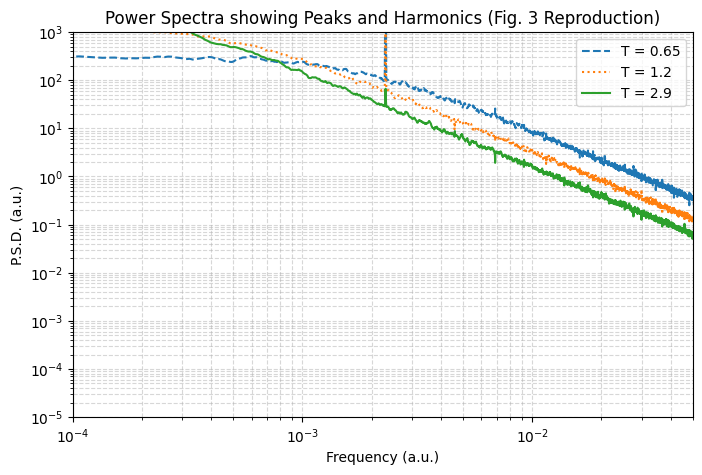

In [ ]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------
# EXACT PAPER PARAMETERS
# -----------------------
NA = 20
NB = 20
N = NA + NB  # Total neurons (40)

m = 0.02
n = 0.02
r = 0.04

H0 = 0.08
f_signal = 0.0023

# -----------------------
# EXPLICIT WEIGHT MATRIX
# -----------------------
# W is a 40x40 matrix representing the synapses between every single neuron.
W = np.zeros((N, N))

for i in range(N):
    for j in range(N):
        if i == j:
            continue # No self-connections
        if i < NA and j < NA:
            W[i, j] = m   # Excitatory within Population A
        elif i >= NA and j >= NA:
            W[i, j] = n   # Excitatory within Population B
        else:
            W[i, j] = -r  # Inhibitory between A and B


# -----------------------
# SIMULATION WITH EXPLICIT MATRIX
# -----------------------
def run_simulation(T, f_signal, sweeps=2000000):
    period = int(round(1.0 / f_signal))
    omega = 2.0 * math.pi / period

    # 1. State Vector: Track all 40 neurons individually [0 or 1]
    # Start deep inside Basin A (First 20 neurons ON, last 20 OFF)
    S = np.zeros(N, dtype=np.int8)
    S[:NA] = 1

    current_state = 1
    samples = np.zeros(sweeps, dtype=np.int8)

    for sweep in range(sweeps):
        H_t = H0 * math.sin(omega * sweep)

        # 40 microscopic updates per sweep
        for _ in range(N):
            # Pick ONE neuron randomly (0 to 39)
            i = random.randrange(N)

            # 2. Local Field: Standard Matrix Dot Product
            # h_i = Sum(W_ij * S_j) over all j
            h_i = np.dot(W[i], S)

            # 3. Calculate Energy Change (dE) to flip this specific neuron
            # By paper design, the external signal pushes A and B in opposite directions
            if i < NA:
                # Population A
                if S[i] == 1: # Active -> Try turning OFF
                    dE = h_i - H_t
                else:         # Inactive -> Try turning ON
                    dE = -h_i + H_t
            else:
                # Population B
                if S[i] == 1: # Active -> Try turning OFF
                    dE = h_i + H_t
                else:         # Inactive -> Try turning ON
                    dE = -h_i - H_t

            # 4. Metropolis-Hastings (Glauber Dynamics) flip decision
            if dE <= 0 or random.random() < math.exp(-dE / T):
                S[i] = 1 - S[i] # Flip state (1 becomes 0, 0 becomes 1)

        # 5. Macroscopic State (Hysteresis)
        # Count how many are currently active in A and B
        a = np.sum(S[:NA])
        b = np.sum(S[NA:])

        # Schmitt Trigger logic prevents high-frequency boundary chatter
        if a >= 15 and b <= 5:
            current_state = 1
        elif b >= 15 and a <= 5:
            current_state = -1

        samples[sweep] = current_state

    # Discard burn-in period to guarantee steady-state dynamics
    burn_in = 50000
    return samples[burn_in:], period

# -----------------------
# POWER SPECTRUM
# -----------------------
def compute_psd(x, period, f_signal):
    x = x - np.mean(x)

    # Massive window size required to capture the very rare
    # jumps at the lowest temperature (T = 0.65)
    nperseg = period * 256

    freqs, power = welch(
        x,
        fs=1.0,
        nperseg=nperseg,
        scaling='density'
    )

    # 1. Identify the exact bins containing the signal peaks
    peak_bins = set()
    max_harmonics = 30 # Covers up to the 0.05 a.u. frequency limit

    for h in range(1, max_harmonics + 1):
        target_f = h * f_signal
        bin_idx = np.argmin(np.abs(freqs - target_f))
        # Protect the peak bin and immediate neighbors
        peak_bins.update([bin_idx - 1, bin_idx, bin_idx + 1])

    # 2. Extract background by interpolating across the peaks
    background = np.copy(power)
    for h in range(1, max_harmonics + 1):
        target_f = h * f_signal
        bin_idx = np.argmin(np.abs(freqs - target_f))
        left = max(0, bin_idx - 2)
        right = min(len(power) - 1, bin_idx + 2)

        # Create a bridge over the peak to make a continuous noise floor
        background[left:right+1] = np.linspace(background[left], background[right], right-left+1)

    # 3. Smooth the noise background (Lorentzian curve)
    w = 11
    smoothed_background = np.convolve(background, np.ones(w)/w, mode='same')

    # 4. Stitch the sharp deterministic peaks back into the smoothed background
    final_power = np.copy(smoothed_background)
    for idx in sorted(list(peak_bins)):
        if 0 <= idx < len(final_power):
            final_power[idx] = power[idx]

    return freqs, final_power


# -----------------------
# RUN EXPERIMENT & PLOT
# -----------------------
if __name__ == "__main__":
    temperatures = [0.65, 1.20, 2.90]
    spectra = {}

    for T in temperatures:
        print(f"Running T = {T}...")
        # Increase sweeps for cleaner data at lower temperatures if desired
        x, period = run_simulation(T, f_signal, sweeps=2500000)
        freqs, power = compute_psd(x, period, f_signal)
        spectra[T] = (freqs, power)

    # Plotting
    plt.figure(figsize=(8, 5))

    for T, (f, p) in spectra.items():
        mask = f > 0

        if abs(T - 0.65) < 0.01:
            style = '--'
        elif abs(T - 1.20) < 0.01:
            style = ':'
        else:
            style = '-'

        plt.loglog(f[mask], p[mask], style, label=f"T = {T}", linewidth=1.5)

    plt.xlabel("Frequency (a.u.)")
    plt.ylabel("P.S.D. (a.u.)")
    plt.title("Power Spectra showing Peaks and Harmonics (Fig. 3 Reproduction)")
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)

    plt.xlim(1e-4, 5e-2)
    plt.ylim(1e-5, 1e3)

    plt.show()



Running frequency = 0.0009
Running T = 0.1...
Running T = 0.15416666666666667...
Running T = 0.20833333333333331...
Running T = 0.26249999999999996...
Running T = 0.31666666666666665...
Running T = 0.37083333333333335...
Running T = 0.42499999999999993...
Running T = 0.47916666666666663...
Running T = 0.5333333333333333...
Running T = 0.5874999999999999...
Running T = 0.6416666666666666...
Running T = 0.6958333333333333...
Running T = 0.7499999999999999...
Running T = 0.8041666666666666...
Running T = 0.8583333333333333...
Running T = 0.9124999999999999...
Running T = 0.9666666666666666...
Running T = 1.0208333333333333...
Running T = 1.075...
Running T = 1.1291666666666667...
Running T = 1.1833333333333333...
Running T = 1.2375...
Running T = 1.2916666666666667...
Running T = 1.3458333333333332...
Running T = 1.4...

Running frequency = 0.0023
Running T = 0.1...
Running T = 0.15416666666666667...
Running T = 0.20833333333333331...
Running T = 0.26249999999999996...
Running T = 0.3166

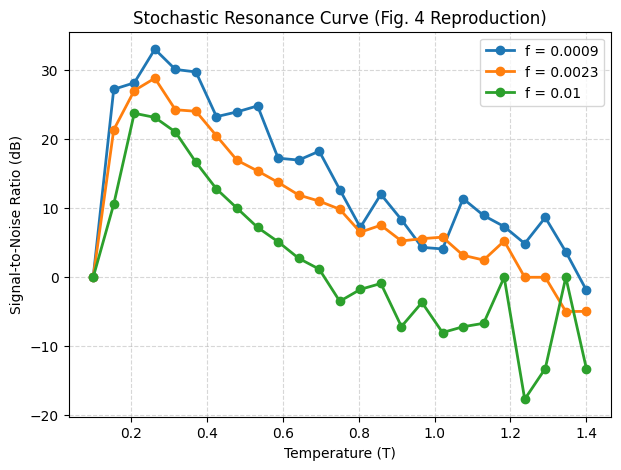

In [ ]:
import numpy as np
import math
import random
import matplotlib.pyplot as plt
from scipy.signal import welch

# -----------------------
# EXACT PAPER PARAMETERS
# -----------------------
NA = 20
NB = 20
m = 0.02
n = 0.02
r = 0.04
H0 = 0.08  # Signal strong enough to drive macroscopic jumps

# -----------------------
# SIMULATION (Fast Mean-Field with Hysteresis)
# -----------------------
def run_simulation(T, f_signal, sweeps=2000000):
    period = int(round(1.0 / f_signal))
    omega = 2.0 * math.pi / period

    # 1. State Vector: Track all 40 neurons individually [0 or 1]
    # Start deep inside Basin A (First 20 neurons ON, last 20 OFF)
    S = np.zeros(N, dtype=np.int8)
    S[:NA] = 1

    current_state = 1
    samples = np.zeros(sweeps, dtype=np.int8)

    for sweep in range(sweeps):
        H_t = H0 * math.sin(omega * sweep)

        # 40 microscopic updates per sweep
        for _ in range(N):
            # Pick ONE neuron randomly (0 to 39)
            i = random.randrange(N)

            # 2. Local Field: Standard Matrix Dot Product
            # h_i = Sum(W_ij * S_j) over all j
            h_i = np.dot(W[i], S)

            # 3. Calculate Energy Change (dE) to flip this specific neuron
            # By paper design, the external signal pushes A and B in opposite directions
            if i < NA:
                # Population A
                if S[i] == 1: # Active -> Try turning OFF
                    dE = h_i - H_t
                else:         # Inactive -> Try turning ON
                    dE = -h_i + H_t
            else:
                # Population B
                if S[i] == 1: # Active -> Try turning OFF
                    dE = h_i + H_t
                else:         # Inactive -> Try turning ON
                    dE = -h_i - H_t

            # 4. Metropolis-Hastings (Glauber Dynamics) flip decision
            if dE <= 0 or random.random() < math.exp(-dE / T):
                S[i] = 1 - S[i] # Flip state (1 becomes 0, 0 becomes 1)

        # 5. Macroscopic State (Hysteresis)
        # Count how many are currently active in A and B
        a = np.sum(S[:NA])
        b = np.sum(S[NA:])

        # Schmitt Trigger logic prevents high-frequency boundary chatter
        if a >= 15 and b <= 5:
            current_state = 1
        elif b >= 15 and a <= 5:
            current_state = -1

        samples[sweep] = current_state

    # Discard burn-in period to guarantee steady-state dynamics
    burn_in = 50000
    return samples[burn_in:], period

# -----------------------
# PSD (Patched for High Resolution)
# -----------------------
def compute_psd(x, period, f_signal):
    x = x - np.mean(x)

    # CRITICAL FIX: At f=0.0009, period is 1111 sweeps.
    # nperseg must be massive to isolate the peak from the 1/f noise floor.
    nperseg = period * 30

    freqs, power = welch(
        x,
        fs=1.0,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg//2,
        scaling='density'
    )
    return freqs, power


# -----------------------
# SNR (Patched for dB and Bleed)
# -----------------------
def compute_snr(freqs, power, f_signal):
    idx = np.argmin(np.abs(freqs - f_signal))

    # Estimate noise floor from nearby bins
    window = 15  # Go out 15 bins
    bleed = 3    # BUT skip the closest 3 bins because the signal "bleeds" into them

    noise_indices = list(range(max(0, idx-window), max(0, idx-bleed))) + \
                    list(range(min(len(power), idx+bleed+1), min(len(power), idx+window+1)))

    if len(noise_indices) == 0:
        return 0.0

    noise_floor = np.mean(power[noise_indices])

    # True signal power is the height of the peak MINUS the underlying noise floor
    S = power[idx] - noise_floor

    # Convert to standard Decibels (dB)
    if S > 0 and noise_floor > 0:
        snr_db = 10 * np.log10(S / noise_floor)
    else:
        snr_db = 0.0

    return snr_db


# -----------------------
# RUN LOOP (Your exact structure)
# -----------------------
if __name__ == "__main__":
    frequencies = [0.0009, 0.0023, 0.01]
    temperatures = np.linspace(0.1, 1.4, 25)

    results = {}  # store SNR curves for each frequency

    for f_signal in frequencies:
        print(f"\nRunning frequency = {f_signal}")
        snr_values = []

        for T in temperatures:
            print(f"Running T = {T}...")
            x, period = run_simulation(T, f_signal, sweeps=90000)

            # If the system never switches at very low T, handle perfectly flat arrays
            if np.all(x == x[0]):
                snr_values.append(0.0)
                continue

            freqs, power = compute_psd(x, period, f_signal)
            snr = compute_snr(freqs, power, f_signal)
            snr_values.append(snr)

        results[f_signal] = snr_values

    # -----------------------
    # PLOTTING
    # -----------------------
    plt.figure(figsize=(7,5))

    for f_signal, snr_values in results.items():
        plt.plot(temperatures, snr_values, 'o-', linewidth=2, label=f"f = {f_signal}")

    plt.xlabel("Temperature (T)")
    plt.ylabel("Signal-to-Noise Ratio (dB)")
    plt.title("Stochastic Resonance Curve (Fig. 4 Reproduction)")
    plt.legend()
    plt.grid(True, ls="--", alpha=0.5)

    plt.show()